# Sprint 2: Zielvariablenkonstruktion und Baseline

## Projekt
Vorhersage von Gehaltsklassen in Stellenausschreibungen mit Daten der Bundesagentur für Arbeit

## Ziel von Sprint 2
In diesem Sprint wird der in Sprint 1 bereinigte Datensatz weiterverarbeitet. Der Schwerpunkt liegt auf der Konstruktion einer Zielvariable für das spätere Machine-Learning-Modell.

Da die Stellenanzeigen selbst kein verlässliches Gehalt enthalten, wird eine Gehaltsklasse als Proxy-Ziel aufgebaut. Dafür werden externe Gehaltsinformationen mit den Berufsangaben der Stellenanzeigen verknüpft.

Am Ende des Sprints soll ein Datensatz vorliegen, der sowohl Eingangsmerkmale als auch eine Zielvariable für die spätere Modellierung enthält.

## Importe

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Datensatz aus Sprint 1 laden

In Sprint 1 wurde ein bereinigter Datensatz mit deutschen Stellenanzeigen erstellt. Dieser Datensatz bildet die Grundlage für den Aufbau der Zielvariable in Sprint 2.

In [3]:
df_jobs = pd.read_csv("../data/jobs_sprint1_cleaned.csv")

print(df_jobs.shape)
df_jobs.head()

(1573, 10)


,id,titel,beruf,arbeitgeber,eintrittsdatum,aktuelleVeroeffentlichungsdatum,ort,region,plz,land
0,12265-500563_JB5112036-S,Data Engineer (m/w/d),Data Engineer,FERCHAU GmbH Niederlassung Bielefeld,2026-04-01,2026-04-01,Bielefeld,Nordrhein-Westfalen,33602,Deutschland
1,12265-500191_JB5110630-S,Data Engineer (m/w/d),Data Engineer,FERCHAU GmbH Niederlassung Rosenheim,2026-04-01,2026-03-31,"Engelsberg, Oberbayern",Bayern,84549,Deutschland
2,12117-28699084-YF-S,Data Engineer (m/w/d),Data Engineer,BTB Blockheizkraftwerks- Träger- und Betreiber...,2026-04-01,2026-04-01,Berlin,Berlin,10585,Deutschland
3,11119-4762322522-S,Data Analyst (m/w/d),Data-Analyst/in,Randstad Professional,2026-04-01,2026-03-31,Frankfurt am Main,Hessen,65929,Deutschland
4,14927-aqxxfm-S,Data Engineer (m/w/d),Data Scientist,Bartels-Langness Handelsgesellschaft mbH & Co. KG,2026-03-31,2026-03-31,Kiel,Schleswig-Holstein,24116,Deutschland


In [4]:
df_jobs.nunique()

id                                 1573
titel                               916
beruf                               219
arbeitgeber                         942
eintrittsdatum                      119
aktuelleVeroeffentlichungsdatum     185
ort                                 709
region                               17
plz                                1002
land                                  1
dtype: int64

## Überblick über die häufigsten Berufe

Da die spätere Gehaltszuordnung vor allem über die Berufsangabe erfolgt, werden zunächst die häufigsten Berufsbezeichnungen betrachtet.

In [5]:
top_berufe = df_jobs["beruf"].value_counts().reset_index()
top_berufe.columns = ["beruf", "anzahl"]

top_berufe.head(25)

,beruf,anzahl
0,Helfer/in - Verkauf,221
1,Softwareentwickler/in,87
2,Betriebswirt/in (Hochschule) - Marketing,87
3,Data Engineer,77
4,Leiter/in - Logistik,63
5,Sachbearbeiter/in - Logistik,61
6,Data Scientist,52
7,Marketingfachkraft/-assistent/in,47
8,Altenpfleger/in,45
9,Data-Analyst/in,38


## Prüfung der KldB-Zuordnung

Für die Verknüpfung mit den externen Entgeltdaten werden KldB-Codes benötigt. Die Berufsangaben aus dem Datensatz aus Sprint 1 wurden deshalb bereits vorab mit dem offiziellen KldB-Verzeichnis der Bundesagentur für Arbeit abgeglichen.

Zunächst wird geprüft, wie vollständig diese Zuordnung ist.

Das Ergebnis dieser Zuordnung liegt als separate CSV-Datei vor und wird in diesem Sprint in den Datensatz übernommen. Auf diese Weise bleibt der Zuordnungsschritt dokumentiert, ohne das Notebook mit umfangreicher Mapping-Logik zu überladen.

In [6]:
df_jobs = pd.read_csv("../data/jobs_sprint1_cleaned_with_kldb.csv")

print(df_jobs.shape)
df_jobs.head()

(1573, 12)


,id,titel,beruf,arbeitgeber,eintrittsdatum,aktuelleVeroeffentlichungsdatum,ort,region,plz,land,kldb,beruf_kldb
0,12265-500563_JB5112036-S,Data Engineer (m/w/d),Data Engineer,FERCHAU GmbH Niederlassung Bielefeld,2026-04-01,2026-04-01,Bielefeld,Nordrhein-Westfalen,33602,Deutschland,43104,Data Engineer
1,12265-500191_JB5110630-S,Data Engineer (m/w/d),Data Engineer,FERCHAU GmbH Niederlassung Rosenheim,2026-04-01,2026-03-31,"Engelsberg, Oberbayern",Bayern,84549,Deutschland,43104,Data Engineer
2,12117-28699084-YF-S,Data Engineer (m/w/d),Data Engineer,BTB Blockheizkraftwerks- Träger- und Betreiber...,2026-04-01,2026-04-01,Berlin,Berlin,10585,Deutschland,43104,Data Engineer
3,11119-4762322522-S,Data Analyst (m/w/d),Data-Analyst/in,Randstad Professional,2026-04-01,2026-03-31,Frankfurt am Main,Hessen,65929,Deutschland,43353,Data-Analyst/in
4,14927-aqxxfm-S,Data Engineer (m/w/d),Data Scientist,Bartels-Langness Handelsgesellschaft mbH & Co. KG,2026-03-31,2026-03-31,Kiel,Schleswig-Holstein,24116,Deutschland,43104,Data Scientist


In [7]:
print("Anzahl fehlender KldB-Codes:", df_jobs["kldb"].isna().sum())
print("Match-Rate:", round(df_jobs["kldb"].notna().mean(), 3))

Anzahl fehlender KldB-Codes: 0
Match-Rate: 1.0


## Vergleich der Spalten `beruf` und `beruf_kldb`

Da beide Spalten potenziell dieselbe Berufsangabe enthalten, wird im Folgenden geprüft, ob sie im gesamten Datensatz identische Werte aufweisen. Fehlende Werte werden dafür einheitlich behandelt und die Texte vor dem Vergleich bereinigt.

In [8]:
vergleich = (
    df_jobs["beruf"].fillna("MISSING").astype(str).str.strip()
    ==
    df_jobs["beruf_kldb"].fillna("MISSING").astype(str).str.strip()
)

print(vergleich.value_counts())

True    1573
Name: count, dtype: int64


Die Prüfung zeigt, dass `beruf` und `beruf_kldb` in allen Zeilen identische Werte enthalten. Die Spalte `beruf_kldb` wird daher als redundant betrachtet und im weiteren Verlauf entfernt.

In [9]:
df_jobs = df_jobs.drop(columns=["beruf_kldb"])
df_jobs.head(1)

,id,titel,beruf,arbeitgeber,eintrittsdatum,aktuelleVeroeffentlichungsdatum,ort,region,plz,land,kldb
0,12265-500563_JB5112036-S,Data Engineer (m/w/d),Data Engineer,FERCHAU GmbH Niederlassung Bielefeld,2026-04-01,2026-04-01,Bielefeld,Nordrhein-Westfalen,33602,Deutschland,43104


## 3-stellige Berufsgruppe aus dem KldB-Code ableiten

Die externe Entgelttabelle liegt nicht auf Ebene der vollständigen 5-stelligen KldB-Codes vor, sondern auf Ebene der 3-stelligen Berufsgruppen. Deshalb wird aus dem vorhandenen KldB-Code zunächst die zugehörige Berufsgruppe abgeleitet.

In [10]:
df_jobs["bg_code"] = df_jobs["kldb"].astype(str).str[:3].astype(int)
print(df_jobs["bg_code"].value_counts())

bg_code
621    241
921    238
431    171
516    151
434    130
813    110
821    104
513     77
433     71
713     35
611     30
273     23
263     17
842     17
831     14
432     13
932     11
832     11
271      9
723      9
714      9
715      9
817      7
722      5
634      5
525      5
232      4
292      4
623      4
121      4
311      3
261      3
632      2
612      2
912      2
825      2
844      2
822      2
732      2
811      2
411      1
733      1
262      1
721      1
924      1
231      1
711      1
221      1
282      1
633      1
913      1
521      1
541      1
Name: count, dtype: int64


## Externe Entgeltdaten laden

Für die Gehaltsinformationen wird eine separate Entgelttabelle verwendet. Diese basiert auf der offiziellen BA-Darstellung „Entgelte nach Berufen im Vergleich“ und enthält Medianentgelte nach Region und 3-stelliger Berufsgruppe.

Die direkte Entgeltatlas-API-Anbindung wurde im Projektverlauf verworfen, da sie nicht stabil reproduzierbar war. Stattdessen wird in dieser Iteration mit einer vorbereiteten tabellarischen Entgeltquelle gearbeitet.

In [11]:
df_salary = pd.read_csv("../data/entgelte_berufsgruppen.csv")

print(df_salary.shape)
df_salary.head()

(848, 4)


,region,bg_code,berufsgruppe,median_entgelt
0,Baden-Württemberg,121,Gartenbau,3.382
1,Baden-Württemberg,221,"Kunststoff,Kautschukherstell.,verarbeit",3.260
2,Baden-Württemberg,231,Papier- und Verpackungstechnik,3.961
3,Baden-Württemberg,232,Technische Mediengestaltung,3.749
4,Baden-Württemberg,261,Mechatronik und Automatisierungstechnik,4.874


## Regionsnamen prüfen und angleichen

Da die Verknüpfung über `region` und `bg_code` erfolgt, wird zunächst geprüft, ob die Regionsnamen in beiden Datensätzen zusammenpassen.

In [12]:
print(sorted(df_jobs["region"].dropna().unique()))
print(sorted(df_salary["region"].dropna().unique()))

['Baden-Württemberg', 'Bayern', 'Berlin', 'Brandenburg', 'Bremen', 'Hamburg', 'Hessen', 'Mecklenburg-Vorpommern', 'Niedersachsen', 'Nordrhein-Westfalen', 'Rheinland-Pfalz', 'Saarland', 'Sachsen', 'Sachsen-Anhalt', 'Schleswig-Holstein', 'Thüringen', 'Unbekannt']
['Baden-Württemberg', 'Bayern', 'Berlin', 'Brandenburg', 'Bremen', 'Hamburg', 'Hessen', 'Mecklenburg-Vorpommern', 'Niedersachsen', 'Nordrhein-Westfalen', 'Rheinland-Pfalz', 'Saarland', 'Sachsen', 'Sachsen-Anhalt', 'Schleswig-Holstein', 'Thüringen']


Dabei zeigt sich, dass im Stellenanzeigendatensatz zusätzlich die Ausprägung `Unbekannt` vorkommt, während diese in der Entgelttabelle nicht enthalten ist. Für Anzeigen mit `region = Unbekannt` kann deshalb später kein Medianentgelt zugeordnet werden. Dies erklärt einen Teil der fehlenden Werte nach dem Merge.

## Entgeltdaten mit den Stellenanzeigen zusammenführen

Die Verknüpfung der Entgelttabelle mit den Stellenanzeigen erfolgt über die Kombination aus `region` und `bg_code`. Auf diese Weise kann jeder Stellenanzeige ein geschätztes Gehaltsniveau auf Ebene der jeweiligen Berufsgruppe und Region zugeordnet werden.

In [13]:
df_merged = df_jobs.merge(
    df_salary,
    on=["region", "bg_code"],
    how="left"
)

print(df_merged.shape)
df_merged.head()

(1573, 14)


,id,titel,beruf,arbeitgeber,eintrittsdatum,aktuelleVeroeffentlichungsdatum,ort,region,plz,land,kldb,bg_code,berufsgruppe,median_entgelt
0,12265-500563_JB5112036-S,Data Engineer (m/w/d),Data Engineer,FERCHAU GmbH Niederlassung Bielefeld,2026-04-01,2026-04-01,Bielefeld,Nordrhein-Westfalen,33602,Deutschland,43104,431,Informatik,5.471
1,12265-500191_JB5110630-S,Data Engineer (m/w/d),Data Engineer,FERCHAU GmbH Niederlassung Rosenheim,2026-04-01,2026-03-31,"Engelsberg, Oberbayern",Bayern,84549,Deutschland,43104,431,Informatik,5.882
2,12117-28699084-YF-S,Data Engineer (m/w/d),Data Engineer,BTB Blockheizkraftwerks- Träger- und Betreiber...,2026-04-01,2026-04-01,Berlin,Berlin,10585,Deutschland,43104,431,Informatik,5.995
3,11119-4762322522-S,Data Analyst (m/w/d),Data-Analyst/in,Randstad Professional,2026-04-01,2026-03-31,Frankfurt am Main,Hessen,65929,Deutschland,43353,433,"IT-Netzwerkt.,-Koord.,-Administr.,-Orga.",6.471
4,14927-aqxxfm-S,Data Engineer (m/w/d),Data Scientist,Bartels-Langness Handelsgesellschaft mbH & Co. KG,2026-03-31,2026-03-31,Kiel,Schleswig-Holstein,24116,Deutschland,43104,431,Informatik,4.824


## Match-Rate prüfen

Nach dem Merge wird geprüft, für wie viele Stellenanzeigen ein Medianentgelt vorliegt.

In [14]:
print("Anteil mit vorhandenem Entgelt:",
      round(df_merged["median_entgelt"].notna().mean(), 3))

print("Anzahl fehlender Entgelte:",
      df_merged["median_entgelt"].isna().sum())

Anteil mit vorhandenem Entgelt: 0.989
Anzahl fehlender Entgelte: 17


In [15]:
df_merged[df_merged["median_entgelt"].isna()][["beruf", "region", "kldb", "bg_code"]].head(20)

,beruf,region,kldb,bg_code
76,Statistiker/in,Brandenburg,41114,411
90,Data-Analyst/in,Unbekannt,43353,433
191,Data-Analyst/in,Unbekannt,43353,433
201,Data Engineer,Unbekannt,43104,431
258,Betriebswirt/in (Hochschule) - Marketing,Unbekannt,92114,921
266,Betriebswirt/in (Hochschule) - Marketing,Unbekannt,92114,921
287,Gestalter/in - visuelles Marketing,Brandenburg,93222,932
331,Marketingfachkraft/-assistent/in,Unbekannt,92112,921
467,Kommunikationswissenschaftler/in,Brandenburg,91244,912
588,Fachkraft - Logistik/Materialwirtschaft,Unbekannt,51312,513


## Nur erfolgreiche Zuordnungen weiterverwenden

Für die weitere Modellierung werden nur Stellenanzeigen verwendet, für die sowohl eine Berufsgruppe als auch ein Medianentgelt vorliegt.
Die wenigen nicht zugeordneten Fälle betreffen vor allem Anzeigen mit fehlender Region („Unbekannt“) oder Berufsgruppen, die in der Entgelttabelle nicht enthalten waren.

In [16]:
df_matched = df_merged.dropna(subset=["median_entgelt"]).copy()

print(df_matched.shape)
df_matched[["beruf", "region", "bg_code", "median_entgelt"]].head(10)

(1556, 14)


,beruf,region,bg_code,median_entgelt
0,Data Engineer,Nordrhein-Westfalen,431,5.471
1,Data Engineer,Bayern,431,5.882
2,Data Engineer,Berlin,431,5.995
3,Data-Analyst/in,Hessen,433,6.471
4,Data Scientist,Schleswig-Holstein,431,4.824
5,Data Scientist,Sachsen,431,4.727
6,Data Engineer,Berlin,431,5.995
7,Data Engineer,Baden-Württemberg,431,6.370
8,Data Engineer,Bayern,431,5.882
9,Data-Analyst/in,Baden-Württemberg,433,6.076


## Gehaltsklassen erzeugen

Da das Ziel des Projekts nicht in der Vorhersage eines exakten individuellen Stellengehalts besteht, sondern in der Schätzung eines berufsgruppenbasierten Gehaltsniveaus, wird im Projekt bewusst eine Klassifikation in Gehaltsklassen statt einer numerischen Regression verwendet.

Es werden drei Klassen gebildet: niedrig, mittel und hoch.

Die Einteilung erfolgt über Tertile des Medianentgelts.

In [17]:
df_matched["gehaltsklasse"] = pd.qcut(
    df_matched["median_entgelt"],
    q=3,
    labels=["niedrig", "mittel", "hoch"]
)

In [18]:
df_matched["gehaltsklasse"].value_counts()

gehaltsklasse
niedrig    522
hoch       518
mittel     516
Name: count, dtype: int64

## Erste Exploration der Zielvariable

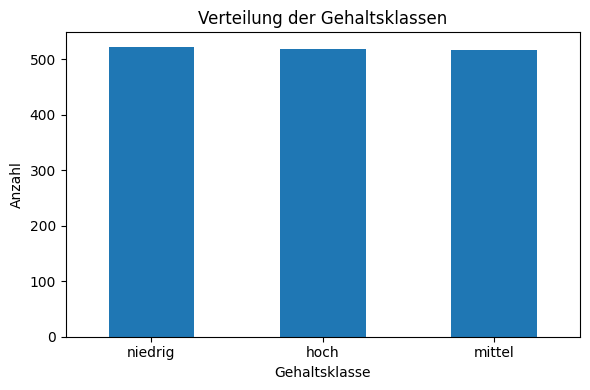

In [19]:
plt.figure(figsize=(6, 4))
df_matched["gehaltsklasse"].value_counts().plot(kind="bar")
plt.title("Verteilung der Gehaltsklassen")
plt.xlabel("Gehaltsklasse")
plt.ylabel("Anzahl")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Überblick über die Entgeltverteilung

In [20]:
df_matched["median_entgelt"].describe()

count    1556.000000
mean        4.499504
std         1.145175
min         2.292000
25%         3.341500
50%         4.311000
75%         5.485000
max         7.550000
Name: median_entgelt, dtype: float64

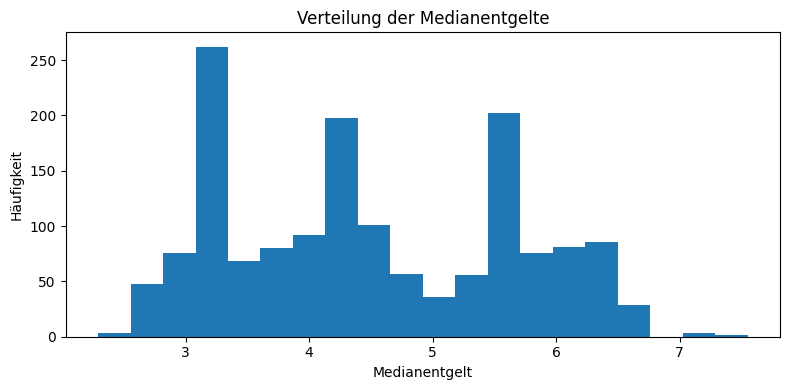

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(df_matched["median_entgelt"], bins=20)
plt.title("Verteilung der Medianentgelte")
plt.xlabel("Medianentgelt")
plt.ylabel("Häufigkeit")
plt.tight_layout()
plt.show()

Die berechneten Grenzen lauten 2.292, 3.789, 5.321 und 7.55. Damit umfasst die Klasse `niedrig` die kleineren Medianentgelte bis 3.789, `mittel` die Werte zwischen 3.789 und 5.321 und `hoch` die größten Medianentgelte ab 5.321.

In [22]:
cats, bins = pd.qcut(
    df_matched["median_entgelt"],
    q=3,
    labels=["niedrig", "mittel", "hoch"],
    retbins=True
)

print("Grenzen:", bins)

Grenzen: [2.292 3.789 5.321 7.55 ]


## Baseline bestimmen

Als einfache Baseline wird die häufigste Gehaltsklasse verwendet. Diese Baseline dient in Sprint 3 als Vergleich für das eigentliche Modell.

In [23]:
majority_class = df_matched["gehaltsklasse"].mode()[0]
baseline_accuracy = (df_matched["gehaltsklasse"] == majority_class).mean()

print("Häufigste Klasse:", majority_class)
print("Baseline Accuracy:", round(baseline_accuracy, 3))

Häufigste Klasse: niedrig
Baseline Accuracy: 0.335


## Datensatz für Sprint 3 speichern

Der erzeugte Datensatz enthält nun die ursprünglichen Merkmale der Stellenanzeigen sowie die neu konstruierte Zielvariable `gehaltsklasse`. Er bildet die Grundlage für die spätere Modellierung.

In [24]:
df_matched.to_csv("../data/jobs_with_salary_classes.csv", index=False)
print("Datensatz gespeichert als jobs_with_salary_classes.csv")

Datensatz gespeichert als jobs_with_salary_classes.csv


## Fazit von Sprint 2

In diesem Sprint wurde eine Zielvariable für das spätere Klassifikationsmodell konstruiert. Da die Stellenanzeigen selbst kein verlässliches Gehalt enthalten, wurde ein externes Medianentgelt als Proxy verwendet.

Die Verknüpfung erfolgte über die 3-stellige Berufsgruppe und die Region. Dadurch konnte für fast alle Stellenanzeigen ein geschätztes Gehaltsniveau ergänzt und anschließend in drei Gehaltsklassen überführt werden. Die hohe Match-Rate zeigt, dass die gewählte Verknüpfung über Berufsgruppe und Region für die Konstruktion der Proxy-Zielvariable praktikabel ist.

Die Zielvariable ist nicht perfekt, da ihre Qualität von der vorherigen KldB-Zuordnung und der Aggregation auf Ebene der Berufsgruppen abhängt. Dennoch liegt nun ein erster modellierbarer Datensatz vor, der in Sprint 3 für Baseline, Modellierung und Evaluation genutzt werden kann.